In [3]:
import xarray as xr
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
from gfatpy.lidar.preprocessing import preprocess
from gfatpy.lidar.utils.utils import signal_to_rcs
from gfatpy.utils.utils import numpy_to_datetime
from gfatpy.utils.plot import color_list
from gfatpy.lidar.preprocessing.lidar_preprocessing_tools import ff_2D_overlap_from_channels
%load_ext autoreload
%autoreload 2

%matplotlib inline

In [4]:
lidar = preprocess(
    r"C:\Users\Usuario\Documents\gitlab\gfatpy\tests\datos\PRODUCTS\alhambra\1a\2023\02\22\alh_1a_Prs_rs_xf_20230222.nc", 
    apply_dt = True, 
    apply_bz = True, 
    apply_ov = False
)
# lidar.to_netcdf('preprocessed_alhambra_20230508.nc')

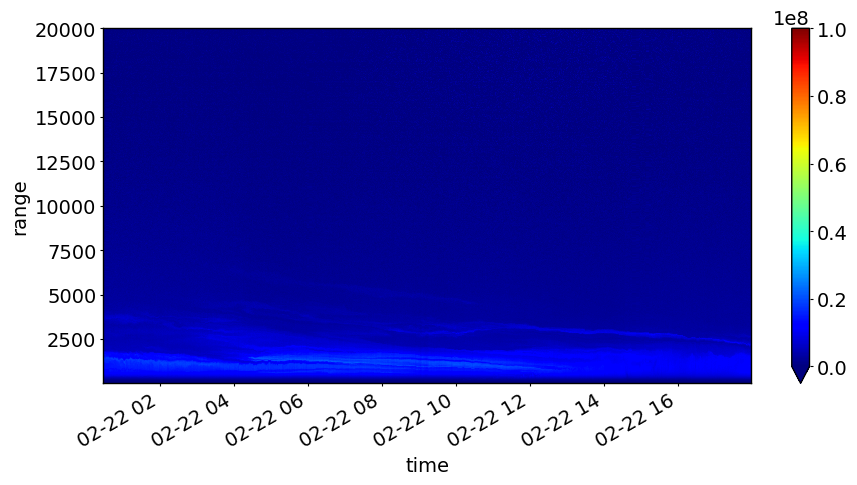

In [4]:
rcs = signal_to_rcs(lidar.signal_532fta,lidar.range)

rcs.plot(x='time',y='range',vmin=0,vmax=1e8,cmap='jet',figsize=(10,5))


In [6]:
ff_channel = '355fpa'
nf_channel = '355npa'
norm_range= (2500, 3500)
rcsff = (lidar[f'signal_{ff_channel}'] * lidar.range**2)
nrcsff = rcsff / rcsff.sel(range=slice(*norm_range)).mean("range")
rcsnf = lidar[f'signal_{nf_channel}'] * lidar.range**2
nrcsnf = rcsnf / rcsnf.sel(range=slice(*norm_range)).mean("range")

overlap_raw = nrcsff.where(nrcsnf > 0., other=1.)/nrcsnf.where(nrcsnf > 0., other=1.)
corrected_nrcsff = nrcsff/overlap_raw

(0.0, 2000.0)

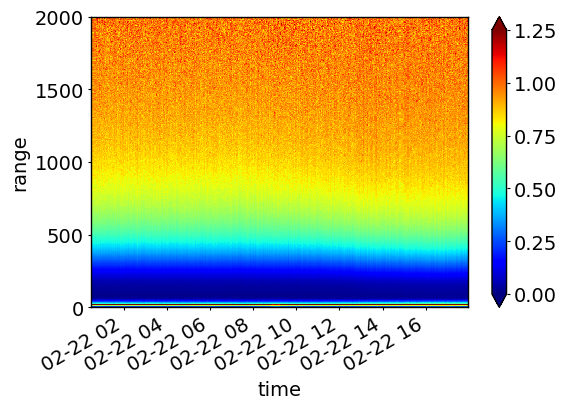

In [10]:
overlap_raw.plot(y='range',cmap='jet',vmin=0,vmax=1.25)
plt.ylim(0,2000)


(0.0, 10.0)

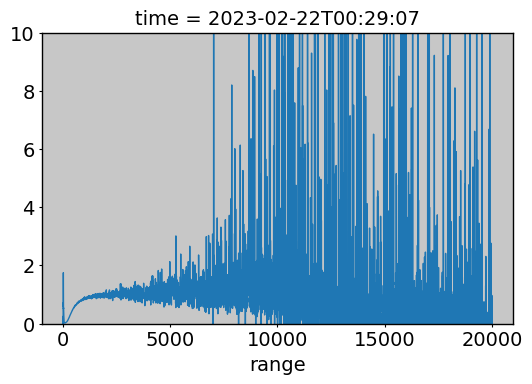

In [97]:
overlap_raw.sel(time=overlap_raw.time[0]).plot()
plt.ylim(0,10)

(0.0, 3000.0)

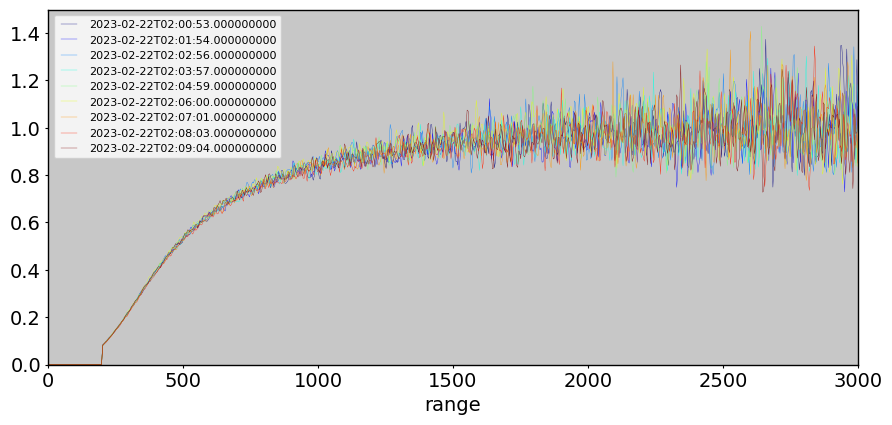

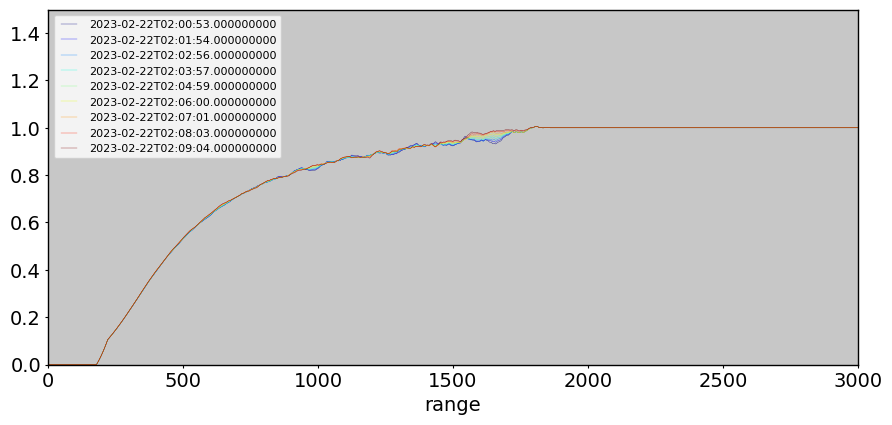

In [104]:
time_tuple = ('2023-02-22T020000.0', '2023-02-22T021000.0')
overlap_raw_sel = overlap_raw.sel(time=slice(*time_tuple))

#Remove firt 200 meters
overlap_raw_sel = overlap_raw_sel.where(overlap_raw_sel.range > 200., other=0.)


fig, ax = plt.subplots(figsize=(10,5))
lines = overlap_raw_sel.plot.line(x='range',lw=0.25,ax=ax)
colors = color_list(len(overlap_raw_sel.time))
[l.set_color(c) for l,c in zip(lines,colors)]
ax.legend(lines, overlap_raw_sel.time.values, fontsize=8, loc='upper left')
ax.set_ylim(0.,1.5)
ax.set_xlim(0,3000)


# Check Upper limit
filtered_overlap = moving_average_xarray(overlap_raw_sel, dim='range', window_size=11)
full_overlap_reached_range = overlap_raw_sel.range[(filtered_overlap > 1.).argmax(dim="range")]
overlap_raw_full = overlap_raw_sel.where(overlap_raw_sel.range <= full_overlap_reached_range, other=1.0)

#Smooth
overlap_raw_full_sm1 = moving_average_xarray(overlap_raw_full, dim=('range', 'time'), window_size=(11,11))

fig, ax = plt.subplots(figsize=(10,5))
lines = overlap_raw_full_sm1.plot.line(x='range',lw=0.25,ax=ax)
colors = color_list(len(overlap_raw_full_sm1.time))
[l.set_color(c) for l,c in zip(lines,colors)]
ax.legend(lines, overlap_raw_full.time.values, fontsize=8, loc='upper left')
ax.set_ylim(0.,1.5)
ax.set_xlim(0,3000)


In [95]:
full_overlap_reached_range

<xarray.DataArray 'range' (time: 9)>
array([18.75, 18.75, 18.75, 18.75, 18.75, 18.75, 18.75, 18.75, 18.75],
      dtype=float32)
Coordinates:
    range    (time) float32 18.75 18.75 18.75 18.75 ... 18.75 18.75 18.75 18.75
  * time     (time) datetime64[ns] 2023-02-22T02:00:53 ... 2023-02-22T02:09:04

In [110]:
overlap = ff_2D_overlap_from_channels(lidar, channel_ff = '1064fta', channel_nf = '1064nta')

(0.0, 2500.0)

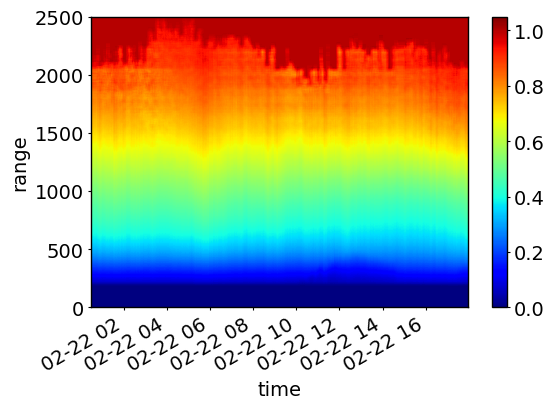

In [111]:
overlap.plot(y='range', vmin=0, vmax=1.05, cmap='jet')
plt.ylim(0,2500)

(0.0, 1500.0)

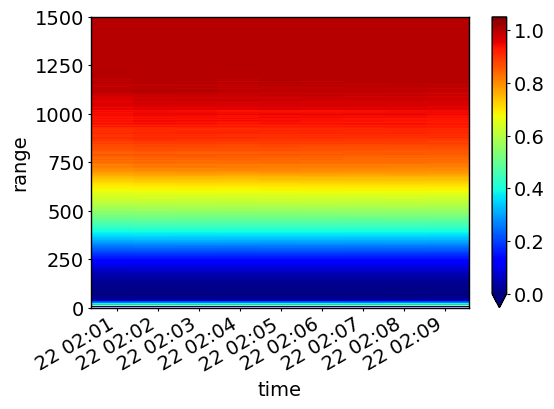

In [26]:
overlap_raw_full.plot(y='range', vmin=0, vmax=1.05, cmap='jet')
plt.ylim(0,1500)

In [ ]:
#REQUIERED
overlap = {}

C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


NameError: name 'overlap' is not defined

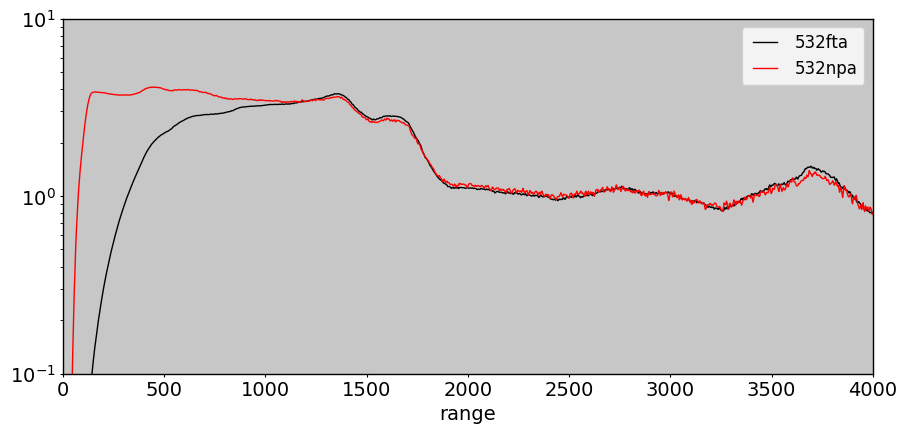

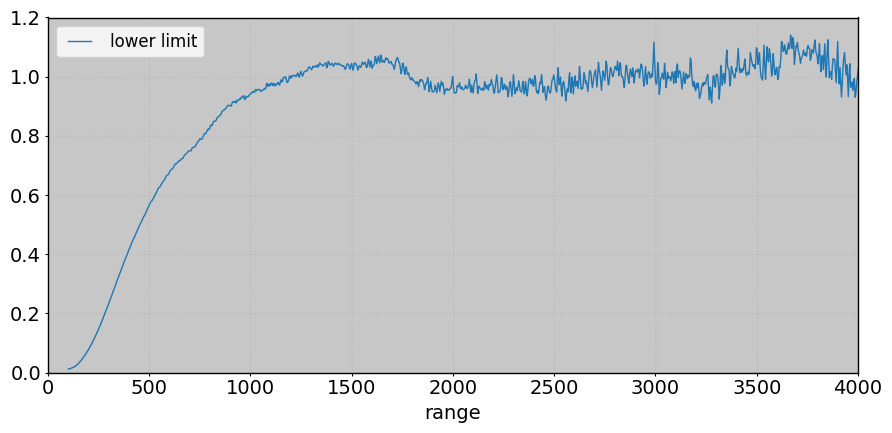

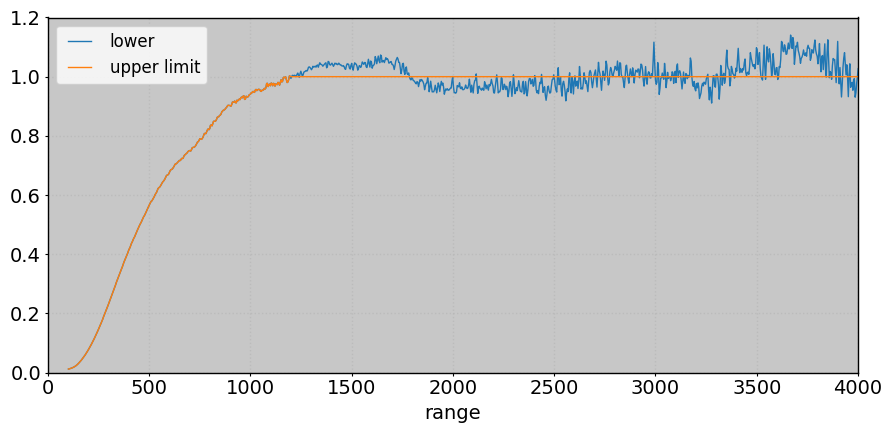

In [9]:
ff_channel = '532fta'
nf_channel = '532npa'
time_smooth = ("20230222T003000", "20230222T010000")
norm_range= (2500, 3500)
rcsff = lidar[f'signal_{ff_channel}'].sel(time=slice(*time_smooth)).mean("time") * lidar.range**2
nrcsff = rcsff / rcsff.sel(range=slice(*norm_range)).mean("range")
rcsnf = lidar[f'signal_{nf_channel}'].sel(time=slice(*time_smooth)).mean("time") * lidar.range**2
nrcsnf = rcsnf / rcsnf.sel(range=slice(*norm_range)).mean("range")

overlap_raw = nrcsff/nrcsnf
corrected_nrcsff = nrcsff/overlap_raw

fig, ax = plt.subplots(figsize=[10,5])
nrcsff.plot(color='k', label=ff_channel, ax=ax)
nrcsnf.plot(color='r', label=nf_channel, ax=ax)
ax.set_yscale('log')
ax.set_ylim(0.1,10)
ax.set_xlim(0,4000)
ax.legend()

#Lower limit
rel_dif = (100*(corrected_nrcsff - nrcsnf)/nrcsnf)

overlap_lower = overlap_raw.copy()
overlap_lower[overlap_raw.range<100] =np.nan
overlap_lower[rel_dif>2.5] = np.nan

fig, ax = plt.subplots(figsize=[10,5])
overlap_lower.plot(label='lower limit', ax=ax)
ax.set_ylim(0,1.2)
ax.set_xlim(0,4000)
ax.legend()
ax.grid()


#Upper limit
median = overlap_lower.rolling(range=11, center=True).median('range')
max_overlap = overlap_lower.range[1 - median.values <0][0]
overlap_upper = overlap_lower.copy()
overlap_upper[overlap_upper.range>max_overlap] = 1.

fig, ax = plt.subplots(figsize=[10,5])
overlap_lower.plot(label='lower', ax=ax)
overlap_upper.plot(label='upper limit', ax=ax)
ax.set_ylim(0,1.2)
ax.set_xlim(0,4000)
ax.legend()
ax.grid()

#Final overlap function
overlap[ff_channel] = overlap_upper.copy()

# #Smooth and Glue
# abs_diff = np.abs(overlap_upper.rolling(range=3,center=True).mean('range').sel(range=slice(0,500)).values- overlap_upper.rolling(range=11,center=True).mean('range').sel(range=slice(0,500)).values)
# glue_range_ov = overlap_upper.range.sel(range=slice(0,500))[np.nanmin(abs_diff)==abs_diff].values.item()
# resolution = (overlap_upper.range[1] -  overlap_upper.range[0]).item()
# overlap_near = overlap_upper.rolling(range=3,center=True).mean('range').sel(range=slice(0,glue_range_ov)).values
# overlap_far = overlap_upper.rolling(range=51,center=True).mean('range').sel(range=slice(glue_range_ov+resolution,overlap_upper.range.max())).values

# overlap_smooth_glue = overlap_raw.copy() 
# overlap_smooth_glue[overlap_smooth_glue.range<(glue_range_ov+resolution)] = overlap_near
# overlap_smooth_glue[overlap_smooth_glue.range>glue_range_ov] = overlap_far

# fig, ax = plt.subplots(figsize=[10,5])
# overlap_lower.plot(label='lower limit', ax=ax)
# overlap_smooth_glue.plot(label='smooth and glue', ax=ax)
# ax.set_ylim(0,1.2)
# ax.set_xlim(0,4000)
# ax.legend()
# ax.grid()

#Check correction
fig, ax = plt.subplots(figsize=[10,5])
nrcsff.plot(color='k', lw=2, label='532nm-ff', ax=ax)
nrcsnf.plot(color='w', lw=3, label='355nm-nf', ax=ax)
ax.plot(nrcsff.range.values, nrcsff.values/overlap_raw, label='ov raw')
ax.plot(nrcsff.range.values, nrcsff.values/overlap_upper, label='ov upper')
# ax.plot(nrcsff.range.values, nrcsff.values/overlap_smooth_glue, label='ov final')
ax.set_yscale('log')
ax.set_ylim(0.8,2)
ax.set_xlim(0,3000)
ax.legend()
ax.grid()

#Relative difference
fig, ax = plt.subplots(figsize=[10,5])
plt.plot(nrcsff.range.values, 1*(nrcsnf-nrcsff)/nrcsnf, label='raw [1=100%]')
plt.plot(nrcsff.range.values, 100*(nrcsnf-nrcsff/overlap_raw)/nrcsnf, label='ov')
plt.plot(nrcsff.range.values, 100*(nrcsnf-nrcsff/overlap_upper)/nrcsnf, label='ov upper')
# plt.plot(nrcsff.range.values, 100*(nrcsnf-nrcsff/overlap_smooth_glue)/nrcsnf, label='final OV')
ax.set_ylim(-1.2,1.2)
ax.set_xlim(0,3000)
ax.legend()
ax.grid()

C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


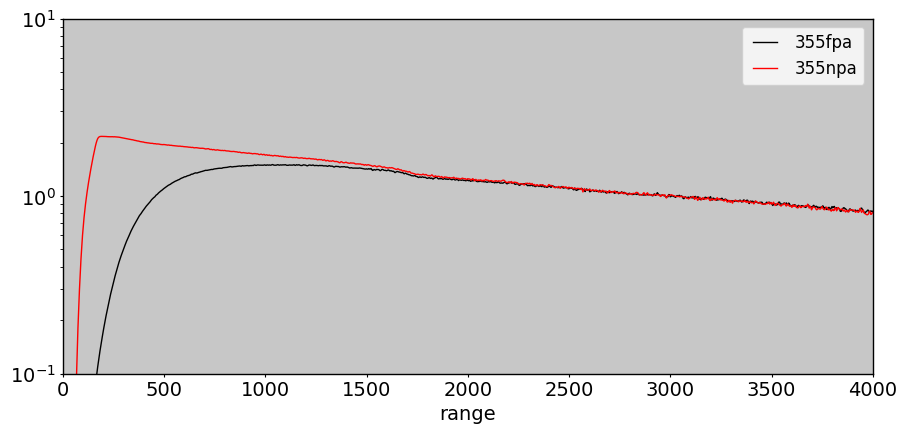

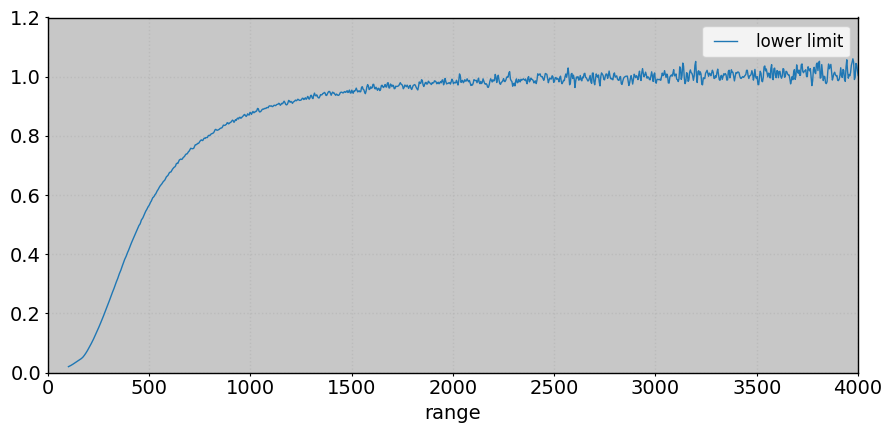

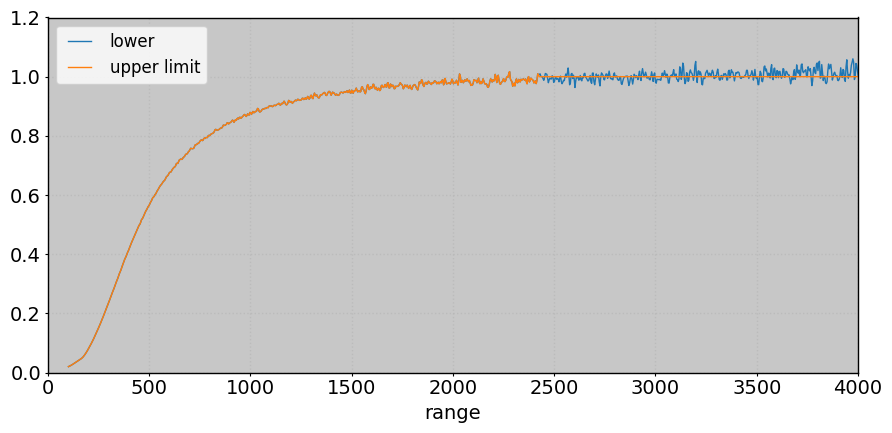

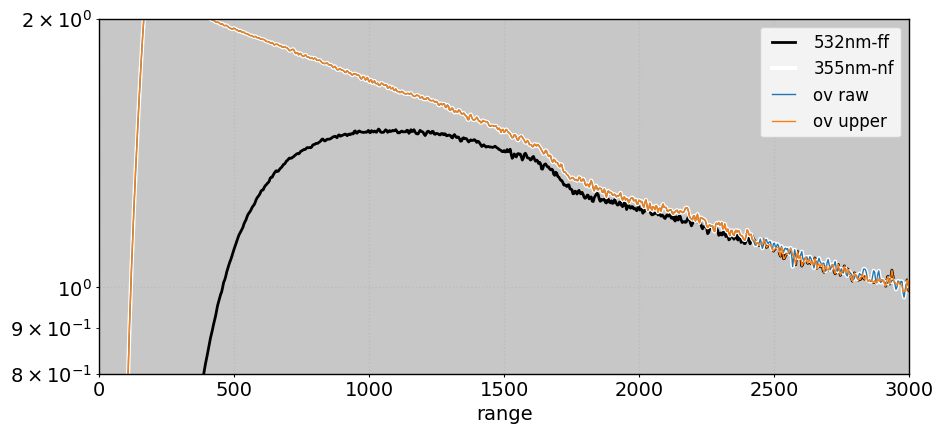

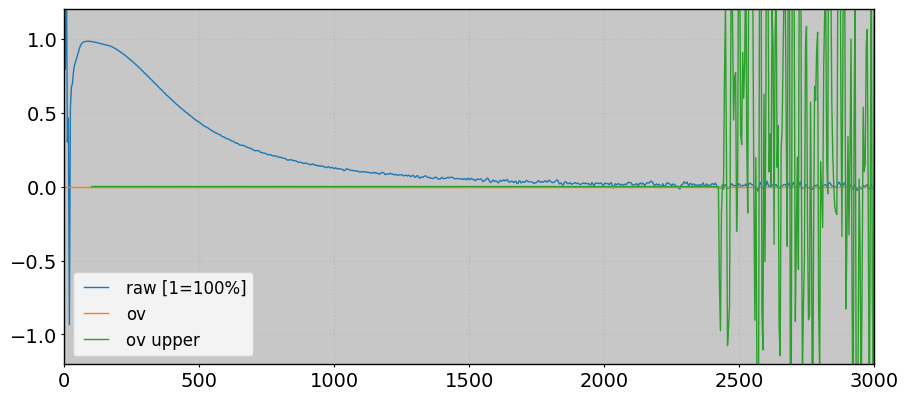

In [18]:
ff_channel = '355fpa'
nf_channel = '355npa'
time_smooth = ("20230510T020000", "20230510T023000")
norm_range= (2500, 3500)
rcsff = lidar[f'signal_{ff_channel}'].sel(time=slice(*time_smooth)).mean("time") * lidar.range**2
nrcsff = rcsff / rcsff.sel(range=slice(*norm_range)).mean("range")
rcsnf = lidar[f'signal_{nf_channel}'].sel(time=slice(*time_smooth)).mean("time") * lidar.range**2
nrcsnf = rcsnf / rcsnf.sel(range=slice(*norm_range)).mean("range")

overlap_raw = nrcsff/nrcsnf
corrected_nrcsff = nrcsff/overlap_raw

fig, ax = plt.subplots(figsize=[10,5])
nrcsff.plot(color='k', label=ff_channel, ax=ax)
nrcsnf.plot(color='r', label=nf_channel, ax=ax)
ax.set_yscale('log')
ax.set_ylim(0.1,10)
ax.set_xlim(0,4000)
ax.legend()

#Lower limit
rel_dif = (100*(corrected_nrcsff - nrcsnf)/nrcsnf)

overlap_lower = overlap_raw.copy()
overlap_lower[overlap_raw.range<100] =np.nan
overlap_lower[rel_dif>2.5] = np.nan

fig, ax = plt.subplots(figsize=[10,5])
overlap_lower.plot(label='lower limit', ax=ax)
ax.set_ylim(0,1.2)
ax.set_xlim(0,4000)
ax.legend()
ax.grid()


#Upper limit
median = overlap_lower.rolling(range=11, center=True).median('range')
max_overlap = overlap_lower.range[1 - median.values <0][0]
overlap_upper = overlap_lower.copy()
overlap_upper[overlap_upper.range>max_overlap] = 1.

fig, ax = plt.subplots(figsize=[10,5])
overlap_lower.plot(label='lower', ax=ax)
overlap_upper.plot(label='upper limit', ax=ax)
ax.set_ylim(0,1.2)
ax.set_xlim(0,4000)
ax.legend()
ax.grid()

#Final overlap function
overlap[ff_channel] = overlap_upper.copy()

# #Smooth and Glue
# abs_diff = np.abs(overlap_upper.rolling(range=3,center=True).mean('range').sel(range=slice(0,500)).values- overlap_upper.rolling(range=11,center=True).mean('range').sel(range=slice(0,500)).values)
# glue_range_ov = overlap_upper.range.sel(range=slice(0,500))[np.nanmin(abs_diff)==abs_diff].values.item()
# resolution = (overlap_upper.range[1] -  overlap_upper.range[0]).item()
# overlap_near = overlap_upper.rolling(range=3,center=True).mean('range').sel(range=slice(0,glue_range_ov)).values
# overlap_far = overlap_upper.rolling(range=51,center=True).mean('range').sel(range=slice(glue_range_ov+resolution,overlap_upper.range.max())).values

# overlap_smooth_glue = overlap_raw.copy() 
# overlap_smooth_glue[overlap_smooth_glue.range<(glue_range_ov+resolution)] = overlap_near
# overlap_smooth_glue[overlap_smooth_glue.range>glue_range_ov] = overlap_far

# fig, ax = plt.subplots(figsize=[10,5])
# overlap_lower.plot(label='lower limit', ax=ax)
# overlap_smooth_glue.plot(label='smooth and glue', ax=ax)
# ax.set_ylim(0,1.2)
# ax.set_xlim(0,4000)
# ax.legend()
# ax.grid()

#Check correction
fig, ax = plt.subplots(figsize=[10,5])
nrcsff.plot(color='k', lw=2, label='532nm-ff', ax=ax)
nrcsnf.plot(color='w', lw=3, label='355nm-nf', ax=ax)
ax.plot(nrcsff.range.values, nrcsff.values/overlap_raw, label='ov raw')
ax.plot(nrcsff.range.values, nrcsff.values/overlap_upper, label='ov upper')
# ax.plot(nrcsff.range.values, nrcsff.values/overlap_smooth_glue, label='ov final')
ax.set_yscale('log')
ax.set_ylim(0.8,2)
ax.set_xlim(0,3000)
ax.legend()
ax.grid()

#Relative difference
fig, ax = plt.subplots(figsize=[10,5])
plt.plot(nrcsff.range.values, 1*(nrcsnf-nrcsff)/nrcsnf, label='raw [1=100%]')
plt.plot(nrcsff.range.values, 100*(nrcsnf-nrcsff/overlap_raw)/nrcsnf, label='ov')
plt.plot(nrcsff.range.values, 100*(nrcsnf-nrcsff/overlap_upper)/nrcsnf, label='ov upper')
# plt.plot(nrcsff.range.values, 100*(nrcsnf-nrcsff/overlap_smooth_glue)/nrcsnf, label='final OV')
ax.set_ylim(-1.2,1.2)
ax.set_xlim(0,3000)
ax.legend()
ax.grid()

C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


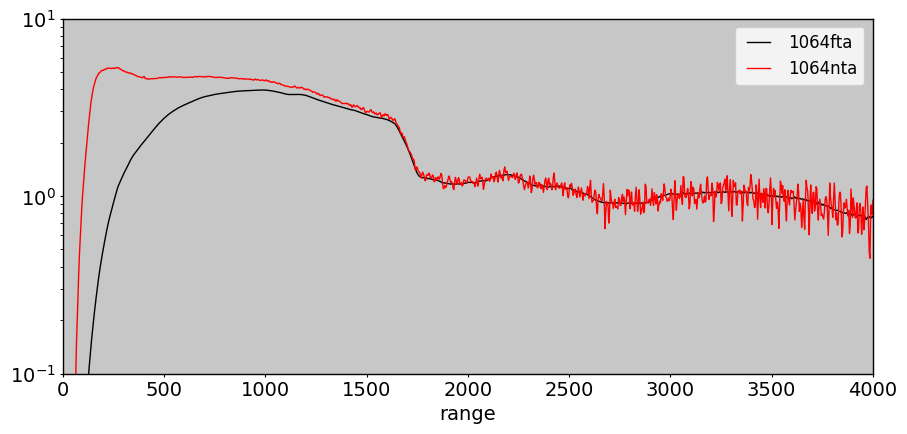

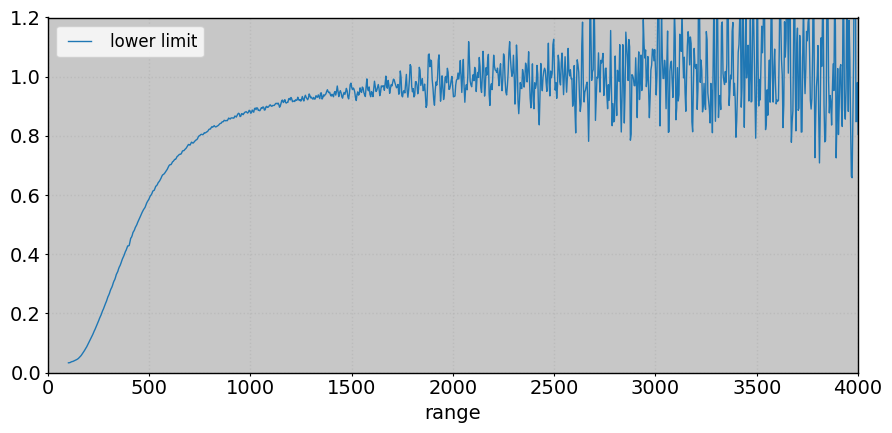

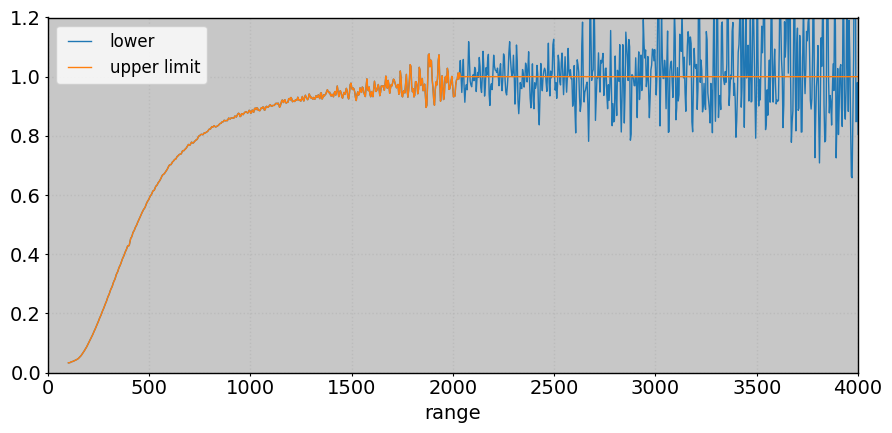

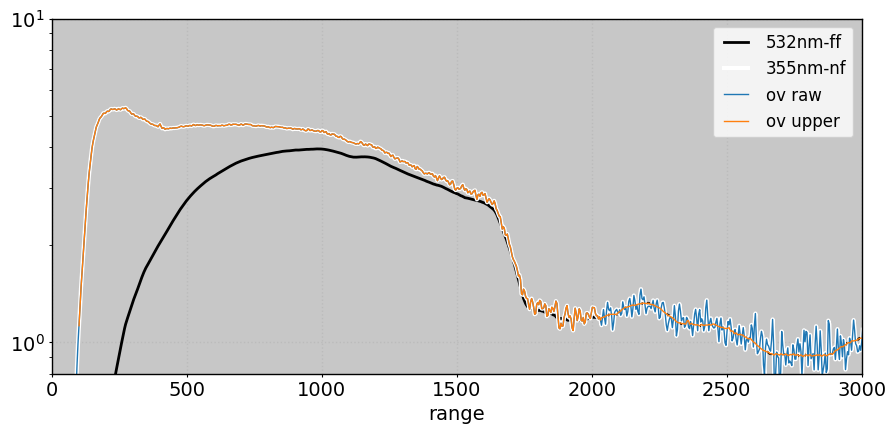

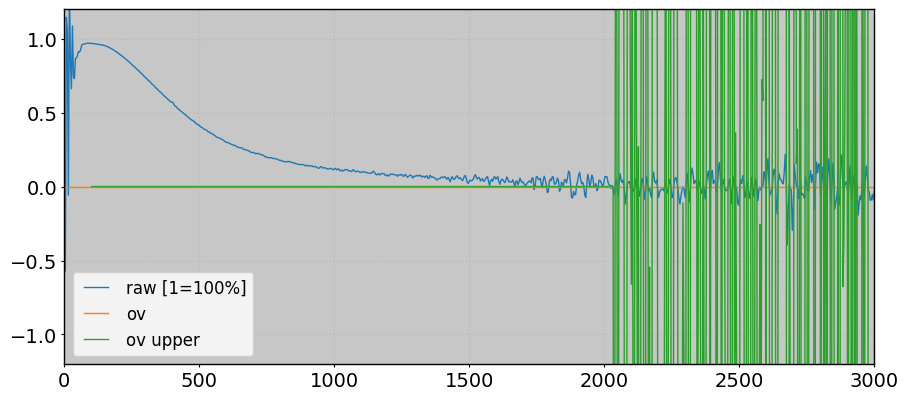

In [22]:
ff_channel = '1064fta'
nf_channel = '1064nta'
time_smooth = ("20230510T020000", "20230510T023000")
norm_range= (2500, 3500)
rcsff = lidar[f'signal_{ff_channel}'].sel(time=slice(*time_smooth)).mean("time") * lidar.range**2
nrcsff = rcsff / rcsff.sel(range=slice(*norm_range)).mean("range")
rcsnf = lidar[f'signal_{nf_channel}'].sel(time=slice(*time_smooth)).mean("time") * lidar.range**2
nrcsnf = rcsnf / rcsnf.sel(range=slice(*norm_range)).mean("range")

overlap_raw = nrcsff/nrcsnf
corrected_nrcsff = nrcsff/overlap_raw

fig, ax = plt.subplots(figsize=[10,5])
nrcsff.plot(color='k', label=ff_channel, ax=ax)
nrcsnf.plot(color='r', label=nf_channel, ax=ax)
ax.set_yscale('log')
ax.set_ylim(0.1,10)
ax.set_xlim(0,4000)
ax.legend()

#Lower limit
rel_dif = (100*(corrected_nrcsff - nrcsnf)/nrcsnf)

overlap_lower = overlap_raw.copy()
overlap_lower[overlap_raw.range<100] =np.nan
overlap_lower[rel_dif>2.5] = np.nan

fig, ax = plt.subplots(figsize=[10,5])
overlap_lower.plot(label='lower limit', ax=ax)
ax.set_ylim(0,1.2)
ax.set_xlim(0,4000)
ax.legend()
ax.grid()


#Upper limit
median = overlap_lower.rolling(range=11, center=True).median('range')
max_overlap = overlap_lower.range[1 - median.values <0][0]
overlap_upper = overlap_lower.copy()
overlap_upper[overlap_upper.range>max_overlap] = 1.

fig, ax = plt.subplots(figsize=[10,5])
overlap_lower.plot(label='lower', ax=ax)
overlap_upper.plot(label='upper limit', ax=ax)
ax.set_ylim(0,1.2)
ax.set_xlim(0,4000)
ax.legend()
ax.grid()

#Final overlap function
overlap[ff_channel] = overlap_upper.copy()

# #Smooth and Glue
# abs_diff = np.abs(overlap_upper.rolling(range=3,center=True).mean('range').sel(range=slice(0,500)).values- overlap_upper.rolling(range=11,center=True).mean('range').sel(range=slice(0,500)).values)
# glue_range_ov = overlap_upper.range.sel(range=slice(0,500))[np.nanmin(abs_diff)==abs_diff].values.item()
# resolution = (overlap_upper.range[1] -  overlap_upper.range[0]).item()
# overlap_near = overlap_upper.rolling(range=3,center=True).mean('range').sel(range=slice(0,glue_range_ov)).values
# overlap_far = overlap_upper.rolling(range=51,center=True).mean('range').sel(range=slice(glue_range_ov+resolution,overlap_upper.range.max())).values

# overlap_smooth_glue = overlap_raw.copy() 
# overlap_smooth_glue[overlap_smooth_glue.range<(glue_range_ov+resolution)] = overlap_near
# overlap_smooth_glue[overlap_smooth_glue.range>glue_range_ov] = overlap_far

# fig, ax = plt.subplots(figsize=[10,5])
# overlap_lower.plot(label='lower limit', ax=ax)
# overlap_smooth_glue.plot(label='smooth and glue', ax=ax)
# ax.set_ylim(0,1.2)
# ax.set_xlim(0,4000)
# ax.legend()
# ax.grid()

#Check correction
fig, ax = plt.subplots(figsize=[10,5])
nrcsff.plot(color='k', lw=2, label='532nm-ff', ax=ax)
nrcsnf.plot(color='w', lw=3, label='355nm-nf', ax=ax)
ax.plot(nrcsff.range.values, nrcsff.values/overlap_raw, label='ov raw')
ax.plot(nrcsff.range.values, nrcsff.values/overlap_upper, label='ov upper')
# ax.plot(nrcsff.range.values, nrcsff.values/overlap_smooth_glue, label='ov final')
ax.set_yscale('log')
ax.set_ylim(0.8,10)
ax.set_xlim(0,3000)
ax.legend()
ax.grid()

#Relative difference
fig, ax = plt.subplots(figsize=[10,5])
plt.plot(nrcsff.range.values, 1*(nrcsnf-nrcsff)/nrcsnf, label='raw [1=100%]')
plt.plot(nrcsff.range.values, 100*(nrcsnf-nrcsff/overlap_raw)/nrcsnf, label='ov')
plt.plot(nrcsff.range.values, 100*(nrcsnf-nrcsff/overlap_upper)/nrcsnf, label='ov upper')
# plt.plot(nrcsff.range.values, 100*(nrcsnf-nrcsff/overlap_smooth_glue)/nrcsnf, label='final OV')
ax.set_ylim(-1.2,1.2)
ax.set_xlim(0,3000)
ax.legend()
ax.grid()

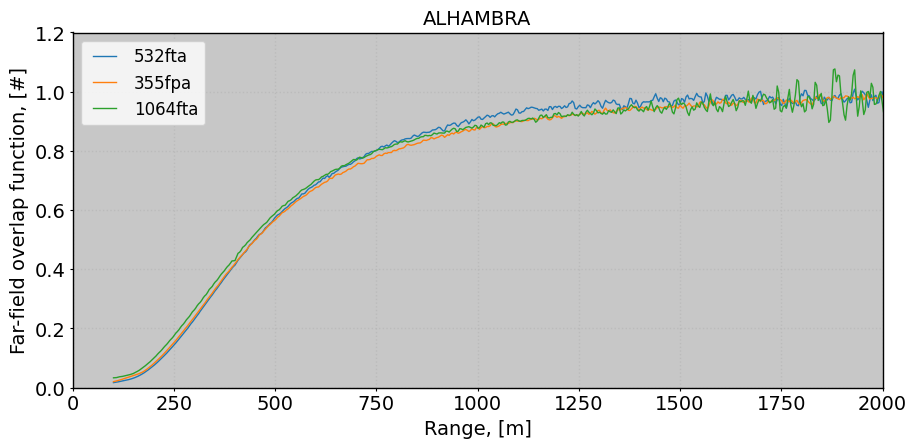

In [29]:
fig, ax = plt.subplots(figsize=[10,5])
overlap['532fta'].plot(label='532fta', ax=ax)
overlap['355fpa'].plot(label='355fpa', ax=ax)
overlap['1064fta'].plot(label='1064fta', ax=ax)
ax.set_title('ALHAMBRA')
ax.set_ylabel('Far-field overlap function, [#]')
ax.set_xlabel('Range, [m]')
ax.set_ylim(0,1.2)
ax.set_xlim(0,2000)
ax.legend()
ax.grid()